In [6]:
import networkx as nx

# Create graph
G = nx.Graph()

# --- Substations (already defined earlier, shortened here) ---
subs_220_132 = ["Colombo B", "Kotugoda", "Veyangoda", "Biyagama",
                "Habarana", "New Habarana", "New Anuradhapura",
                "Anuradhapura", "Vavuniya", "Kilinochchi", "Chunnakam"]

subs_132_33 = ["Trincomalee", "Kurunegala", "Pannala", "Kandy",
               "Polonnaruwa", "Badulla", "Galle", "Hambantota",
               "Ampara", "Batticaloa", "Monaragala", "Ratmalana"]

subs_132_11 = ["Kelanitissa", "Sapugaskanda", "Kolonnawa", "Matara"]

# Add nodes
for s in subs_220_132:
    G.add_node(s, voltage="220/132 kV", type="Grid Substation")
for s in subs_132_33:
    G.add_node(s, voltage="132/33 kV", type="Grid Substation")
for s in subs_132_11:
    G.add_node(s, voltage="132/11 kV", type="Grid Substation")

# --- Transmission lines (edges) ---
# 220 kV
edges_220 = [
    ("Colombo B", "Kotugoda"),
    ("Kotugoda", "Veyangoda"),
    ("Veyangoda", "Biyagama"),
    ("Biyagama", "Habarana"),
    ("Habarana", "New Habarana"),
    ("New Habarana", "Vavuniya"),
    ("Vavuniya", "Kilinochchi"),
    ("Kilinochchi", "Chunnakam"),
    ("Habarana", "New Anuradhapura"),
    ("New Anuradhapura", "Anuradhapura"),
    ("Anuradhapura", "Vavuniya")
]

# 132 kV
edges_132 = [
    ("Colombo B", "Ratmalana"),
    ("Colombo B", "Sapugaskanda"),
    ("Kolonnawa", "Kelanitissa"),
    ("Pannala", "Kurunegala"),
    ("Polpitiya", "Kandy"),
    ("Kandy", "Polonnaruwa"),
    ("Polonnaruwa", "Trincomalee"),
    ("Badulla", "Monaragala"),
    ("Hambantota", "Galle"),
    ("Ampara", "Batticaloa")
]

# Add edges with attributes
for u, v in edges_220:
    G.add_edge(u, v, voltage=220, type="OHL")
for u, v in edges_132:
    G.add_edge(u, v, voltage=132, type="OHL")

# Quick summary
print("Total substations:", G.number_of_nodes())
print("Total transmission lines:", G.number_of_edges())


Total substations: 28
Total transmission lines: 21


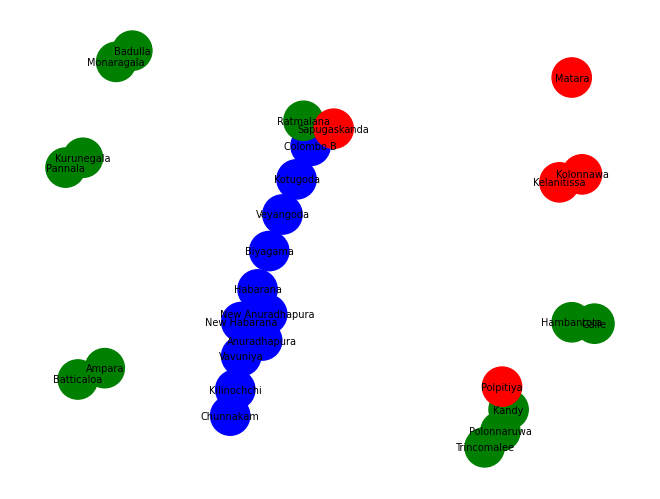

In [8]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)

# Color nodes by type
color_map = []
for n, attr in G.nodes(data=True):
    voltage = attr.get("voltage", "")
    if "220/132" in voltage:
        color_map.append("blue")
    elif "132/33" in voltage:
        color_map.append("green")
    else:
        color_map.append("red")

# Draw
nx.draw(G, pos, with_labels=True, node_color=color_map,
        node_size=800, font_size=7, edge_color="gray")
plt.show()
